# Patient Treatment in Emergency Department
## Business Information Systems Project 2026

Process mining analysis applied to an emergency department event log.

The project analyses patient pathways through:
- data preparation and quality checks;
- performance analysis;
- variant analysis and Directly-Follows Graphs;
- process discovery and conformance checking;
- pattern-based feature generation.

The aim is to describe the observed process, identify its main characteristics,
and formulate potential improvement hypotheses based on the available data.

**Instructions:** install the dependencies in the next cell, make
`dataset_for_exam.csv` available in your Google Drive, and run the cells in order.

In Colab, the dataset is read from the Google Drive path specified in the initial cell.
The `results_simplified` and `figures_simplified` folders are created automatically.


In [1]:
# Install the required libraries.
%pip install pm4py==2.7.23.8 pandas numpy matplotlib nbformat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 19.2 MB/s eta 0:00:00


In [2]:
# Connect to Google Drive and set the dataset path.

from google.colab import drive
drive.mount('/content/drive')

import os
os.environ['BIS_DATASET'] = '/content/drive/MyDrive/dataset_for_exam.csv'

Mounted at /content/drive


## C01 | Environment and Reproducibility


In [3]:
# Import libraries and configure the analysis environment.
from pathlib import Path
import os, json, hashlib, sys, platform, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pm4py
from pm4py.util import constants
constants.SHOW_PROGRESS_BAR = False
from IPython.display import display, Image
warnings.filterwarnings('ignore', category=FutureWarning)
BASE = Path.cwd()
OUT = BASE / 'results_simplified'; FIG = BASE / 'figures_simplified'
OUT.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
SEED = 24092026
plt.rcParams.update({'figure.dpi':130, 'axes.spines.top':False, 'axes.spines.right':False,
                     'font.size':10, 'axes.titleweight':'bold'})
def showfig(name):
    plt.tight_layout(); plt.savefig(FIG/name, bbox_inches='tight'); plt.close()
    display(Image(filename=str(FIG/name)))
def table(df, name):
    df.to_csv(OUT/(name+'.csv'),index=False)
    display(df)
versions = {'python':platform.python_version(),'pandas':pd.__version__,
            'numpy':np.__version__,'pm4py':pm4py.__version__,'seed':SEED}
print(versions)




  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




{'python': '3.13.15', 'pandas': '2.2.3', 'numpy': '2.1.3', 'pm4py': '2.7.23.8', 'seed': 24092026}


## C02 | Data Loading and Initial Checks

In [4]:
# In Colab, the dataset path is set through BIS_DATASET in the initial cell.
candidates = [Path(os.environ.get('BIS_DATASET','dataset_for_exam.csv')),
              BASE/'data/dataset_for_exam.csv',BASE.parent.parent/'data/dataset_for_exam.csv']
DATA = next((p for p in candidates if p.is_file()), None)
if DATA is None:
    try:
        from google.colab import files
        print('Upload dataset_for_exam.csv downloaded from Ariel.')
        uploaded = files.upload()
        csv_names = [name for name in uploaded if name.lower().endswith('.csv')]
        if len(csv_names) != 1:
            raise ValueError('Upload exactly one CSV file: the exam dataset.')
        DATA = Path(csv_names[0])
    except ImportError:
        raise FileNotFoundError('Place dataset_for_exam.csv here or set BIS_DATASET.')
raw = pd.read_csv(DATA, dtype={'stay_id':'string','diagnosis_code':'string'})
original_columns = raw.columns.tolist()
required = ['stay_id','time','activity']
assert set(required).issubset(raw.columns)
raw['_row'] = np.arange(len(raw))
raw['_time'] = pd.to_datetime(raw['time'], errors='coerce')
missing_key = raw[required].isna().any(axis=1) | raw['_time'].isna()
raw_valid = raw.loc[~missing_key].copy()
exact_duplicates = raw_valid.duplicated(original_columns)
# Only duplicates across ALL columns are removed; their number is checked against the data.
detail = raw_valid.loc[~exact_duplicates].copy()
key = ['stay_id','_time','activity']
audit = {'input_rows':len(raw),'input_cases':raw.stay_id.nunique(),
         'missing_key_rows':int(missing_key.sum()),'exact_duplicate_rows':int(exact_duplicates.sum()),
         'repeated_event_key_rows':int(detail.duplicated(key).sum()),
         'sha256':hashlib.sha256(DATA.read_bytes()).hexdigest()}
table(pd.DataFrame({'column':original_columns,
                    'missing_rows':[raw[c].isna().sum() for c in original_columns]}),'missing_by_column')
print(audit)


,column,missing_rows
0,stay_id,0
1,time,0
2,activity,0
3,gender,23295
4,race,23295
5,arrival_transport,23295
6,disposition,21463
7,diagnosis_sequence,21466
8,diagnosis_code,21466
9,diagnosis_description,21466


{'input_rows': 25115, 'input_cases': 1820, 'missing_key_rows': 0, 'exact_duplicate_rows': 0, 'repeated_event_key_rows': 8289, 'sha256': '2f177d64384e7c2a73c03849002b6b853193dc7ab798de236db0b964dd69f8b9'}


## C03 | Data Preparation and Event Granularity

In [5]:
# Several rows may describe different clinical details of the same recorded occurrence.
# Keep the detailed table and create one process event for each stay, timestamp, and activity.
def order_events(df):
    z = df.copy()
    # If two activities share a timestamp, keep Enter first and Discharge last.
    z['_boundary_order'] = z.activity.map({'Enter the ED': -1, 'Discharge from the ED': 1}).fillna(0)
    return z.sort_values(['stay_id', '_time', '_boundary_order', '_row'], kind='stable').drop(columns='_boundary_order')

events = order_events(detail.sort_values('_row').drop_duplicates(['stay_id', '_time', 'activity']))

# Build one row per stay for case-level attributes and performance measures.
case = pd.DataFrame(index=sorted(detail.stay_id.unique()))
case.index.name = 'stay_id'
conflicts = []
for col in ['gender', 'race', 'arrival_transport', 'disposition', 'acuity']:
    vals = detail.groupby('stay_id')[col].agg(lambda s: tuple(pd.unique(s.dropna())))
    case[col] = vals.map(lambda v: v[0] if len(v) == 1 else np.nan)
    conflicts.append({'attribute': col,
                      'missing_cases': int((vals.map(len) == 0).sum()),
                      'conflicting_cases': int((vals.map(len) > 1).sum())})

# Keep all diagnosis codes because many stays contain more than one diagnosis.
case['diagnosis_codes'] = detail.groupby('stay_id').diagnosis_code.agg(lambda s: tuple(sorted(set(s.dropna()))))
case['diagnosis_count'] = case.diagnosis_codes.map(len)
case['event_count'] = events.groupby('stay_id').size()
case['first'] = events.groupby('stay_id')._time.min()
case['last'] = events.groupby('stay_id')._time.max()

for activity, col in [('Enter the ED', 'arrival'),
                      ('Triage in the ED', 'triage'),
                      ('Discharge from the ED', 'exit')]:
    case[col] = events.loc[events.activity == activity].groupby('stay_id')._time.agg('max' if col == 'exit' else 'min')

case['los_min'] = (case.exit - case.arrival).dt.total_seconds() / 60
case['arrival_at_start'] = case.arrival.notna() & case.arrival.eq(case['first'])
case['exit_at_end'] = case.exit.notna() & case.exit.eq(case['last'])
case['complete'] = case.arrival_at_start & case.exit_at_end & case.los_min.ge(0)
case_all = case.copy()

valid_ids = case.index[case.complete]
process = events[events.stay_id.isin(valid_ids)].copy()
case = case.loc[valid_ids].copy()

audit.update({'process_events': len(process),
              'complete_cases': len(case),
              'excluded_incomplete_cases': int((~case_all.complete).sum()),
              'multi_diagnosis_cases': int((case.diagnosis_count > 1).sum())})

table(pd.DataFrame(conflicts), 'case_attributes_quality')
table(pd.DataFrame({
    'activity': detail.activity.value_counts().index,
    'raw_rows': detail.activity.value_counts().values,
    'process_events': detail.activity.value_counts().index.map(events.activity.value_counts())
}), 'event_granularity')
print(audit)

assert len(case) > 0, 'No complete cases: check the activities and timestamps.'

,attribute,missing_cases,conflicting_cases
0,gender,0,0
1,race,0,0
2,arrival_transport,0,0
3,disposition,0,0
4,acuity,56,0


,activity,raw_rows,process_events
0,Medicine reconciliation,6112,2120
1,Vital sign check,5909,5909
2,Medicine dispensations,5802,3337
3,Discharge from the ED,3652,1820
4,Triage in the ED,1820,1820
5,Enter the ED,1820,1820


{'input_rows': 25115, 'input_cases': 1820, 'missing_key_rows': 0, 'exact_duplicate_rows': 0, 'repeated_event_key_rows': 8289, 'sha256': '2f177d64384e7c2a73c03849002b6b853193dc7ab798de236db0b964dd69f8b9', 'process_events': 16826, 'complete_cases': 1820, 'excluded_incomplete_cases': 0, 'multi_diagnosis_cases': 1093}


## C04 | Variant Analysis

,variant,sequence,cases,coverage,cumulative_coverage
0,V1,Enter the ED > Triage in the ED > Vital sign c...,77,0.042308,0.042308
1,V2,Enter the ED > Triage in the ED > Vital sign c...,59,0.032418,0.074725
2,V3,Enter the ED > Triage in the ED > Discharge fr...,49,0.026923,0.101648
3,V4,Enter the ED > Triage in the ED > Medicine dis...,46,0.025275,0.126923
4,V5,Enter the ED > Triage in the ED > Medicine rec...,34,0.018681,0.145604
5,V6,Enter the ED > Triage in the ED > Vital sign c...,32,0.017582,0.163187
6,V7,Enter the ED > Triage in the ED > Vital sign c...,32,0.017582,0.180769
7,V8,Enter the ED > Triage in the ED > Vital sign c...,31,0.017033,0.197802
8,V9,Enter the ED > Vital sign check > Triage in th...,23,0.012637,0.210440
9,V10,Enter the ED > Vital sign check > Triage in th...,23,0.012637,0.223077


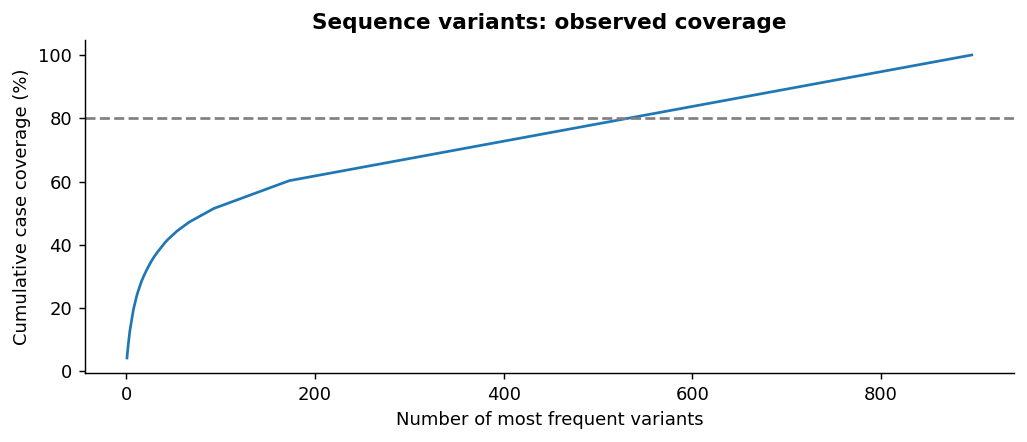

Number of variants: 896
Top variant coverage: 4.23 %
Top 10 coverage: 22.31 %


In [6]:
# A variant is the ordered sequence of activities followed by one stay.
sequences = process.groupby('stay_id').activity.agg(tuple)
variants = sequences.value_counts()

audit.update({'variants': len(variants),
              'top1_coverage': float(variants.iloc[0] / len(case)),
              'top10_coverage': float(variants.iloc[:10].sum() / len(case))})

vr = pd.DataFrame({
    'variant': ['V' + str(i + 1) for i in range(len(variants))],
    'sequence': [' > '.join(v) for v in variants.index],
    'cases': variants.values
})
vr['coverage'] = vr.cases / len(case)
vr['cumulative_coverage'] = vr.coverage.cumsum()

table(vr.head(10), 'top_variants')
vr.to_csv(OUT / 'all_variants.csv', index=False)

plt.figure(figsize=(8, 3.5))
plt.plot(np.arange(1, len(vr) + 1), 100 * vr.cumulative_coverage)
plt.axhline(80, ls='--', color='gray')
plt.xlabel('Number of most frequent variants')
plt.ylabel('Cumulative case coverage (%)')
plt.title('Sequence variants: observed coverage')
showfig('variant_coverage.png')

print('Number of variants:', len(variants))
print('Top variant coverage:', round(100 * audit['top1_coverage'], 2), '%')
print('Top 10 coverage:', round(100 * audit['top10_coverage'], 2), '%')

## C05 | Performance and Repeated Activities

,metric,minutes
0,n,1820.000000
1,mean,408.375760
2,median,301.000000
3,q25,194.241667
4,q75,458.250000
5,p90,748.500000
6,p95,1159.200000
7,max,5065.000000


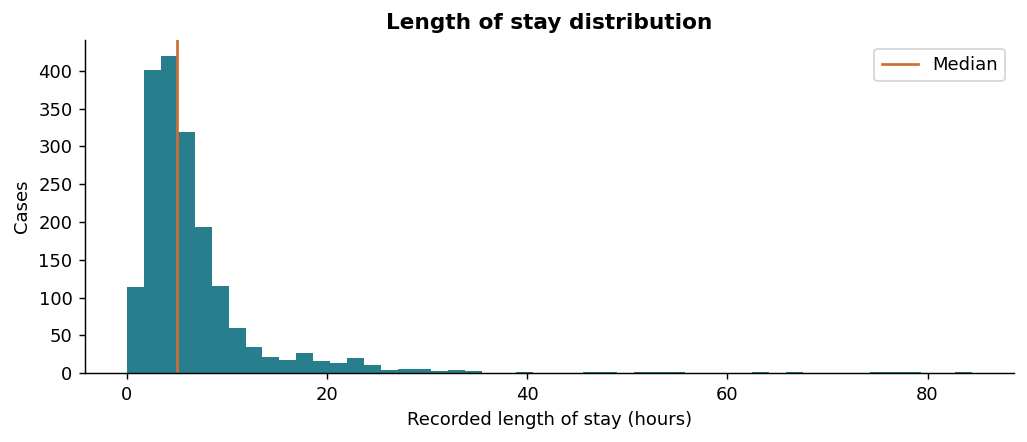

,activity,cases_with_activity,repeated_cases,rate_among_exposed,rate_all_cases
0,Discharge from the ED,1820,0,0.000000,0.000000
1,Enter the ED,1820,0,0.000000,0.000000
2,Medicine dispensations,1218,764,0.627258,0.419780
3,Medicine reconciliation,1021,430,0.421156,0.236264
4,Triage in the ED,1820,0,0.000000,0.000000
5,Vital sign check,1688,1322,0.783175,0.726374


In [7]:
# LOS is measured from Enter the ED to Discharge from the ED.
def summary(s):
    s = s.dropna()
    return pd.Series({'n': len(s), 'mean': s.mean(), 'median': s.median(),
                      'q25': s.quantile(.25), 'q75': s.quantile(.75),
                      'p90': s.quantile(.9), 'p95': s.quantile(.95), 'max': s.max()})

los = summary(case.los_min)
audit['los_summary'] = los.to_dict()
table(los.rename('minutes').rename_axis('metric').reset_index(), 'los_summary')

plt.figure(figsize=(8, 3.5))
plt.hist(case.los_min / 60, bins=50, color='#277f8e')
plt.axvline(case.los_min.median() / 60, color='#cc6f36', label='Median')
plt.legend()
plt.xlabel('Recorded length of stay (hours)')
plt.ylabel('Cases')
plt.title('Length of stay distribution')
showfig('los_distribution.png')

# Repeated activities are counted descriptively; repetition is not automatically classified as waste.
counts = pd.crosstab(process.stay_id, process.activity)
reps = []
for activity in counts:
    exposed = int(counts[activity].gt(0).sum())
    repeated = int(counts[activity].gt(1).sum())
    reps.append({'activity': activity,
                 'cases_with_activity': exposed,
                 'repeated_cases': repeated,
                 'rate_among_exposed': repeated / exposed,
                 'rate_all_cases': repeated / len(case)})
rework = pd.DataFrame(reps)
table(rework, 'repetition')

## C06 | Descriptive Group Comparison

The unit of analysis is the stay (stay_id), which does not necessarily represent a distinct person. Medians and distributions describe associations, not causal effects. No statistical significance tests are performed.


,attribute,group,n,mean,median,q25,q75,p90,p95,max
0,acuity,1.0,129.0,346.987468,275.000000,197.000000,407.00,573.253333,999.800000,1324.0
1,acuity,2.0,609.0,533.844034,366.000000,245.000000,566.00,1066.600000,1413.200000,5065.0
2,acuity,3.0,877.0,374.491885,292.483333,194.250000,441.00,650.800000,1084.800000,2917.0
3,acuity,4.0,142.0,181.373239,171.000000,108.250000,220.00,307.700000,362.650000,824.0
4,acuity,5.0,7.0,162.714286,88.000000,52.500000,174.50,332.800000,445.900000,559.0
5,acuity,nan,56.0,322.287500,204.500000,139.395833,401.25,822.500000,1019.250000,1187.0
6,arrival_transport,AMBULANCE,706.0,495.322757,357.500000,239.000000,553.00,992.000000,1327.750000,5065.0
7,arrival_transport,HELICOPTER,9.0,294.000000,264.000000,211.000000,280.00,469.200000,565.600000,662.0
8,arrival_transport,OTHER,8.0,336.906250,251.000000,193.937500,437.75,560.000000,651.000000,742.0
9,arrival_transport,UNKNOWN,87.0,185.700958,166.000000,88.000000,252.00,354.020000,452.500000,666.0


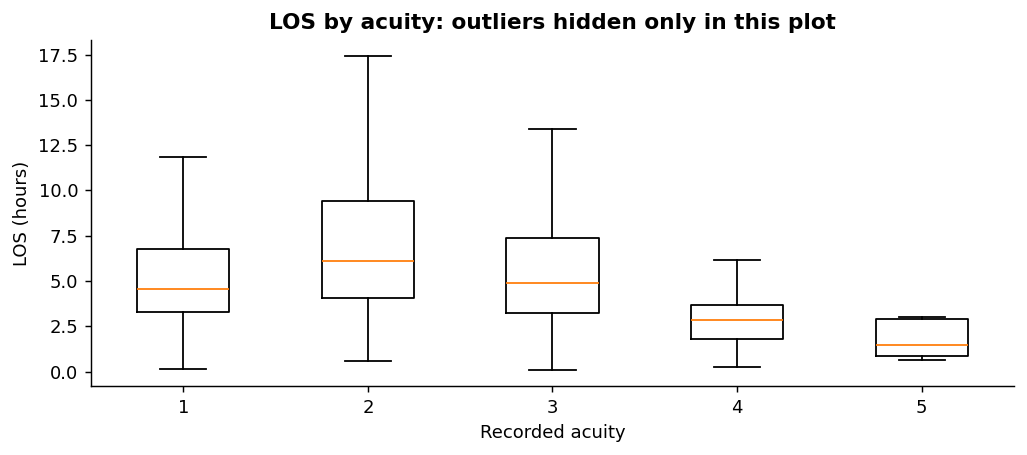

,acuity,n_ambulance,n_walkin,median_ambulance_min,median_walkin_min,median_difference_min
0,1.0,79,20,305.616667,308.0,-2.383333
1,2.0,325,254,401.000000,355.5,45.500000
2,3.0,248,597,354.000000,283.0,71.000000
3,4.0,12,128,222.500000,154.0,68.500000


Descriptive differences do not establish causality or statistical significance.


In [8]:
# Statistical unit: stay_id. Repeated stays by the same patient cannot be identified.
segments=[]
for attr in ['acuity','arrival_transport','disposition']:
    for label,g in case.groupby(attr,dropna=False):
        segments.append({'attribute':attr,'group':str(label),**summary(g.los_min).to_dict()})
seg=pd.DataFrame(segments);table(seg,'segment_performance')
labels=sorted(case.acuity.dropna().unique())
plt.figure(figsize=(8,3.6));plt.boxplot([case.loc[case.acuity==v,'los_min']/60 for v in labels],tick_labels=[str(int(v)) for v in labels],showfliers=False)
plt.xlabel('Recorded acuity');plt.ylabel('LOS (hours)');plt.title('LOS by acuity: outliers hidden only in this plot');showfig('los_acuity.png')
# Descriptive ambulance/walk-in comparison within the same acuity level.
# Sample sizes and medians remain visible even for small groups; no statistical inference.
strat=[]
for acu in labels:
    a=case.loc[(case.acuity==acu)&(case.arrival_transport=='AMBULANCE'),'los_min']
    b=case.loc[(case.acuity==acu)&(case.arrival_transport=='WALK IN'),'los_min']
    if len(a) and len(b):
        strat.append({'acuity':acu,'n_ambulance':len(a),'n_walkin':len(b),
                      'median_ambulance_min':a.median(),'median_walkin_min':b.median(),
                      'median_difference_min':a.median()-b.median()})
table(pd.DataFrame(strat, columns=['acuity','n_ambulance','n_walkin',
    'median_ambulance_min','median_walkin_min','median_difference_min']),'arrival_stratified')
print('Descriptive differences do not establish causality or statistical significance.')


## C07 | Directly-Follows Graphs

The frequency DFG shows how often one activity directly follows another. The performance DFG adds the median time between consecutive recorded events; these intervals should not be interpreted as pure waiting or processing time.

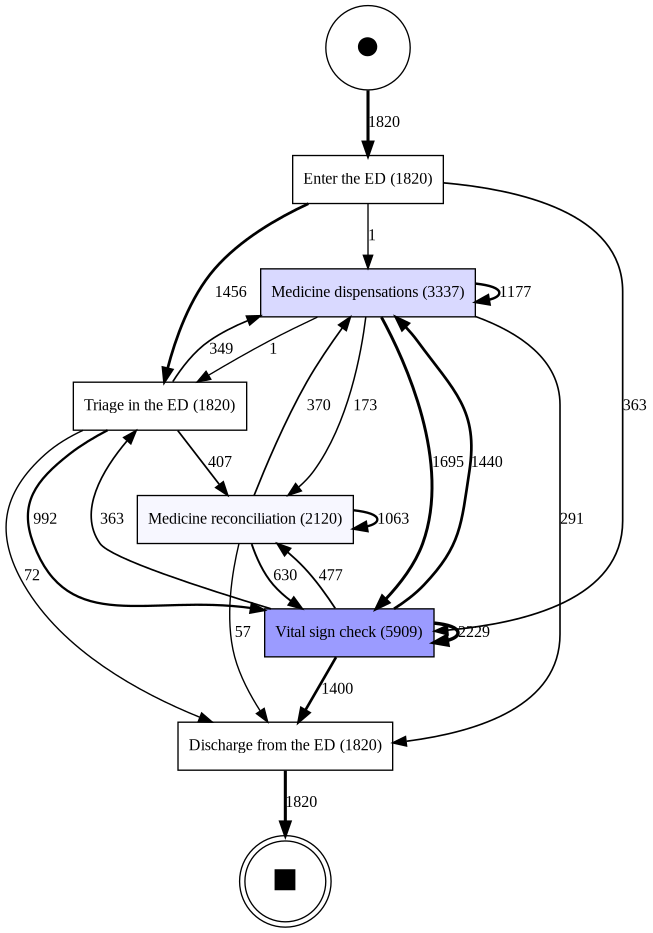

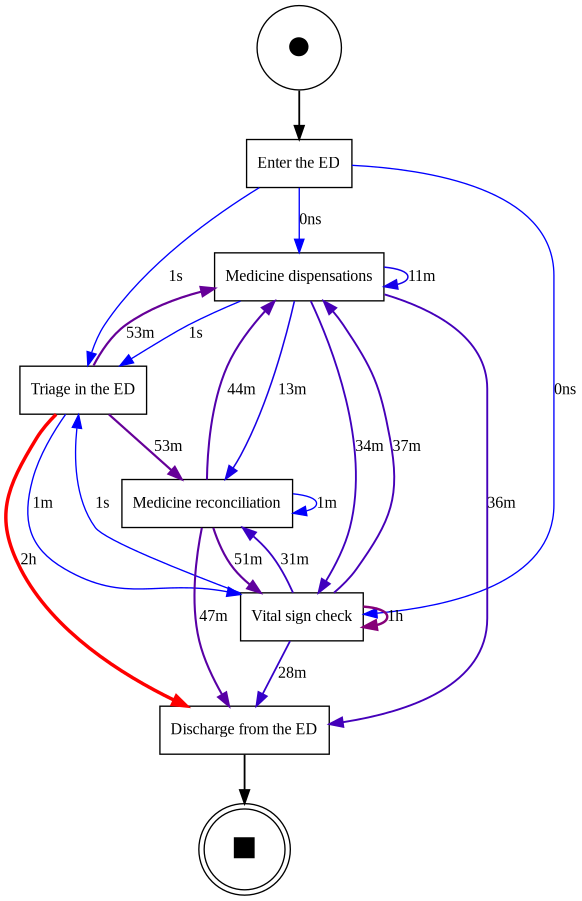

In [9]:
# Convert the simplified process table to the format used by PM4Py.
def pm_frame(df):
    z = df[['stay_id', 'activity', '_time']].rename(columns={
        'stay_id': 'case:concept:name',
        'activity': 'concept:name',
        '_time': 'time:timestamp'
    }).copy()
    z['case:concept:name'] = z['case:concept:name'].astype(str)
    return z

logdf = pm_frame(process)
log = pm4py.convert_to_event_log(logdf)

# Frequency DFG.
dfg, start_activities, end_activities = pm4py.discover_dfg(log)
pm4py.save_vis_dfg(dfg, start_activities, end_activities,
                   str(FIG / 'dfg_frequency.png'), rankdir='TB')
display(Image(filename=str(FIG / 'dfg_frequency.png')))

# Performance DFG using the median interval between consecutive recorded events.
perf_dfg, perf_start, perf_end = pm4py.discover_performance_dfg(log)
pm4py.save_vis_performance_dfg(perf_dfg, perf_start, perf_end,
                               str(FIG / 'dfg_performance.png'),
                               aggregation_measure='median', rankdir='TB')
display(Image(filename=str(FIG / 'dfg_performance.png')))

## C08 | Process Discovery and Model Comparison

Compare a small set of understandable models. Fitness measures how well the model can reproduce the observed log; precision measures how much extra behaviour the model allows. The F1 score is the harmonic mean of fitness and precision and is used here only to choose a balanced candidate.

Inductive full {'fitness': 1.0, 'precision': 0.736, 'f1': 0.8479}
Heuristics {'fitness': 0.8936, 'precision': 0.6213, 'f1': 0.733}
Inductive top1 {'fitness': 0.6665, 'precision': 0.9428, 'f1': 0.7809}
Inductive top2 {'fitness': 0.971, 'precision': 0.7901, 'f1': 0.8713}
Inductive top3 {'fitness': 0.9823, 'precision': 0.8053, 'f1': 0.885}
Inductive top4 {'fitness': 0.8727, 'precision': 0.9581, 'f1': 0.9134}
Inductive top5 {'fitness': 0.8106, 'precision': 0.9993, 'f1': 0.8951}
Inductive top6 {'fitness': 0.8634, 'precision': 0.9858, 'f1': 0.9205}
Inductive top7 {'fitness': 0.8421, 'precision': 0.9903, 'f1': 0.9102}
Inductive top8 {'fitness': 0.8421, 'precision': 0.9903, 'f1': 0.9102}
Inductive top9 {'fitness': 0.8614, 'precision': 0.9744, 'f1': 0.9144}
Inductive top10 {'fitness': 0.8614, 'precision': 0.9744, 'f1': 0.9144}
Inductive top25 {'fitness': 0.9932, 'precision': 0.8515, 'f1': 0.9169}
Inductive top50 {'fitness': 1.0, 'precision': 0.7393, 'f1': 0.8501}


,model,fitness,precision,f1,discovery_cases,discovery_coverage,places,transitions,arcs
0,Inductive full,1.000000,0.735996,0.847923,1820,1.000000,15,18,40
1,Heuristics,0.893630,0.621350,0.733022,1820,1.000000,12,20,46
2,Inductive top1,0.666464,0.942767,0.780895,77,0.042308,5,4,8
3,Inductive top2,0.971041,0.790106,0.871279,136,0.074725,5,5,10
4,Inductive top3,0.982340,0.805269,0.885035,185,0.101648,7,8,16
5,Inductive top4,0.872660,0.958055,0.913366,231,0.126923,8,10,20
6,Inductive top5,0.810565,0.999323,0.895101,265,0.145604,8,11,22
7,Inductive top6,0.863426,0.985768,0.920550,297,0.163187,9,12,24
8,Inductive top7,0.842115,0.990261,0.910199,329,0.180769,9,11,24
9,Inductive top8,0.842115,0.990261,0.910199,360,0.197802,9,11,24


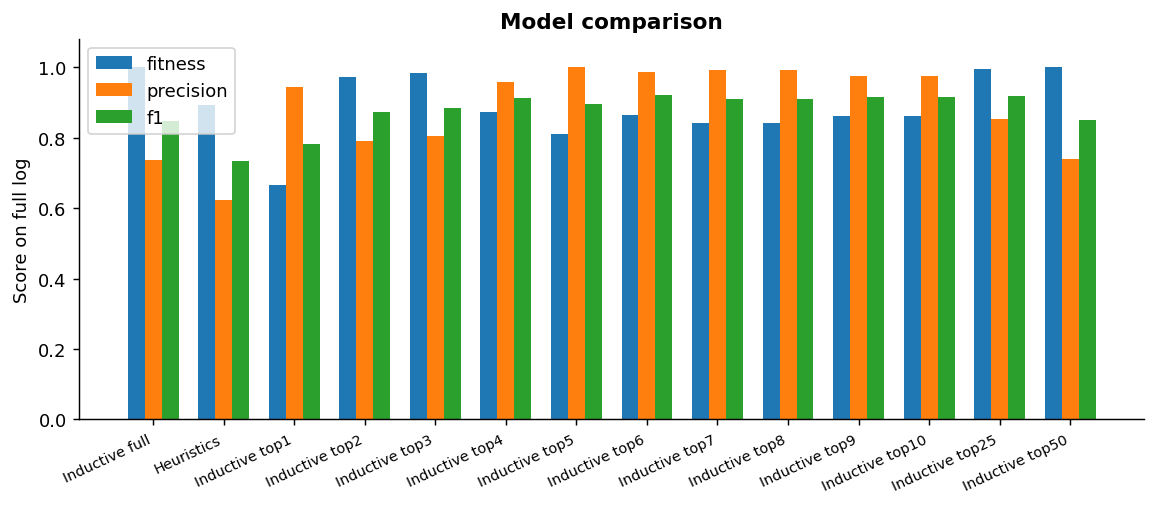

In [10]:
# compare full-log baseline models and several top-variant Inductive models.
models = {}
model_rows = []

def evaluate(name, net_tuple, discovery_log):
    net, im, fm = net_tuple
    fit = pm4py.fitness_token_based_replay(log, net, im, fm)
    precision = pm4py.precision_token_based_replay(log, net, im, fm)
    fitness = fit['log_fitness']
    f1 = 2 * fitness * precision / (fitness + precision) if fitness + precision else 0
    row = {'model': name,
           'fitness': fitness,
           'precision': precision,
           'f1': f1,
           'discovery_cases': len(discovery_log),
           'discovery_coverage': len(discovery_log) / len(log),
           'places': len(net.places),
           'transitions': len(net.transitions),
           'arcs': len(net.arcs)}
    model_rows.append(row)
    models[name] = net_tuple
    print(name, {k: round(row[k], 4) for k in ['fitness', 'precision', 'f1']})

# Baseline models discovered from the full log.
evaluate('Inductive full', pm4py.discover_petri_net_inductive(log, noise_threshold=0), log)
evaluate('Heuristics', pm4py.discover_petri_net_heuristics(log, dependency_threshold=.5), log)

# Simpler models discovered from the most frequent variants and evaluated on the full log.
for k in list(range(1, 11)) + [25, 50]:
    selected_variants = set(variants.index[:k])
    ids = set(sequences[sequences.isin(selected_variants)].index)
    sublog = pm4py.convert_to_event_log(logdf[logdf['case:concept:name'].isin(ids)])
    evaluate('Inductive top' + str(k),
             pm4py.discover_petri_net_inductive(sublog, noise_threshold=0),
             sublog)

quality = pd.DataFrame(model_rows)
table(quality, 'model_quality')

plt.figure(figsize=(9, 4))
x = np.arange(len(quality))
w = .24
for j, col in enumerate(['fitness', 'precision', 'f1']):
    plt.bar(x + (j - 1) * w, quality[col], width=w, label=col)
plt.xticks(x, quality.model, rotation=25, ha='right', fontsize=8)
plt.ylim(0, 1.08)
plt.ylabel('Score on full log')
plt.legend()
plt.title('Model comparison')
showfig('model_comparison.png')

## C09 | Model Selection

Select the model with the highest F1 score among the tested candidates. This gives a simple and transparent balance between fitness and precision.

Selected model: Inductive top6
Fitness: 0.863
Precision: 0.986
F1: 0.921


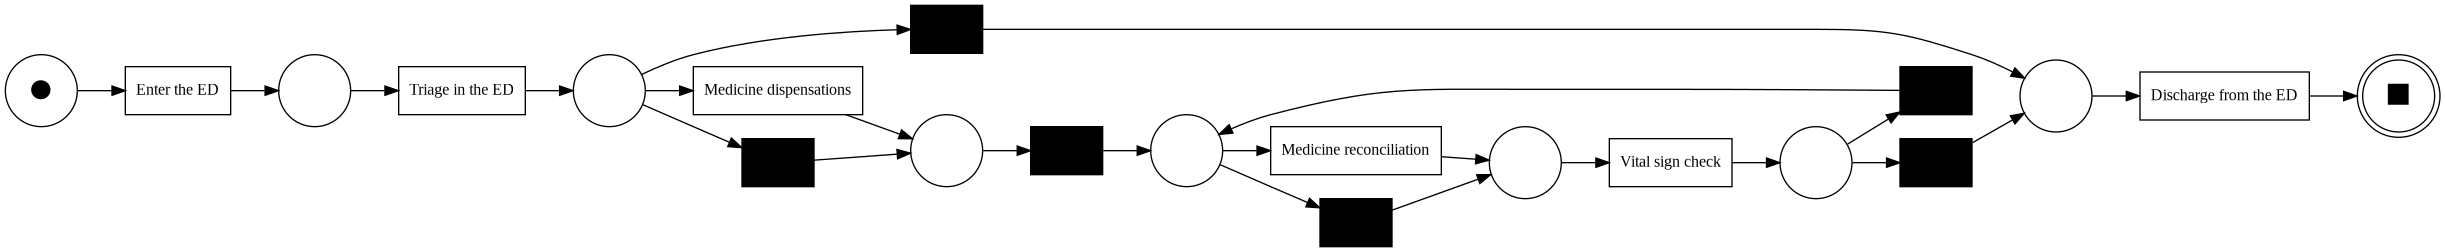

In [11]:
# Select the balanced candidate using the F1 score calculated in C08.
best_row = quality.loc[quality.f1.idxmax()]
best_name = best_row.model
best_net, best_im, best_fm = models[best_name]

print('Selected model:', best_name)
print('Fitness:', round(best_row.fitness, 3))
print('Precision:', round(best_row.precision, 3))
print('F1:', round(best_row.f1, 3))

# Save and display the selected Petri net.
pm4py.save_vis_petri_net(best_net, best_im, best_fm,
                         str(FIG / 'selected_petri_net.png'), rankdir='LR')
pm4py.write_pnml(best_net, best_im, best_fm, str(OUT / 'selected_model.pnml'))
display(Image(filename=str(FIG / 'selected_petri_net.png')))

audit['selected_model'] = best_name
audit['selected_model_scores'] = {
    'fitness': float(best_row.fitness),
    'precision': float(best_row.precision),
    'f1': float(best_row.f1)
}

## C10 | Conformance Checking

Token-based replay checks whether the recorded traces can be reproduced by the selected Petri net. Conformance to the model indicates structural similarity; it does not prove clinical appropriateness.

In [12]:
# Token-based replay provides a clear case-level conformance check.
diag = pm4py.conformance_diagnostics_token_based_replay(
    log, best_net, best_im, best_fm, return_diagnostics_dataframe=True)

conformance = pd.DataFrame([{
    'cases': len(diag),
    'fitting_cases': int(diag.is_fit.sum()),
    'nonfitting_cases': int((~diag.is_fit).sum()),
    'fitting_pct': 100 * float(diag.is_fit.mean()),
    'mean_trace_fitness': float(diag.trace_fitness.mean())
}])
table(conformance, 'conformance_summary')

case['trace_fitness'] = diag.set_index('case_id').trace_fitness
audit['selected_tbr'] = conformance.iloc[0].to_dict()
print(conformance.to_string(index=False))

,cases,fitting_cases,nonfitting_cases,fitting_pct,mean_trace_fitness
0,1820,432,1388,23.736264,0.874158


 cases  fitting_cases  nonfitting_cases  fitting_pct  mean_trace_fitness
  1820            432              1388    23.736264            0.874158


## C11 | Pattern-Based Feature Generation

Use a simple binary mapping **φ = (P1, P2)**:
- **P1 = 1** if acuity is 1–3, otherwise 0 for acuity 4–5;
- **P2 = 1** if the patient arrived by ambulance, otherwise 0.

Cases with missing acuity or an unknown arrival mode are excluded from this specific comparison rather than being automatically coded as 0. The four resulting patterns are compared by frequency, median LOS, and number of sequence variants.

,pattern_P1P2,meaning,cases,median_los_min,mean_los_min,sequence_variants
2,10,acuity 1-3 + non-ambulance,886,301.0,397.790105,466
3,11,acuity 1-3 + ambulance,652,363.0,507.896881,471
0,00,acuity 4-5 + non-ambulance,135,154.0,171.785185,51
1,01,acuity 4-5 + ambulance,12,222.5,262.500000,11


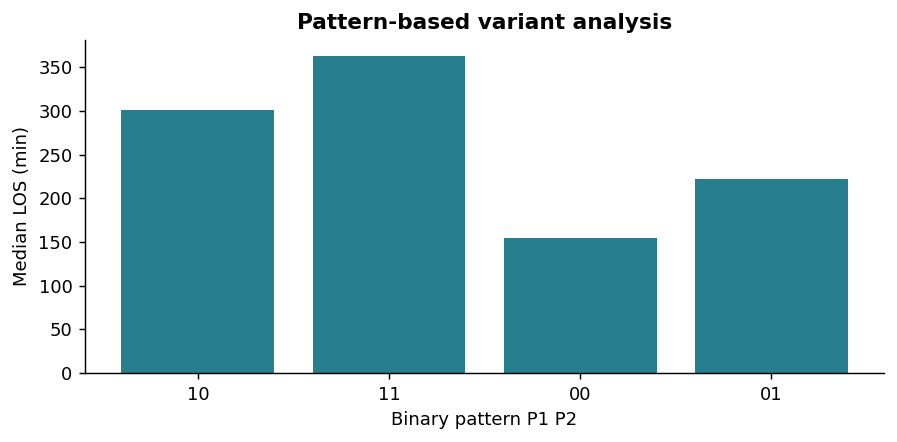

In [13]:
# Build the binary patterns requested by the assignment using two meaningful case attributes.
known = case.acuity.notna() & case.arrival_transport.notna() & case.arrival_transport.ne('UNKNOWN')
pattern_case = case.loc[known].copy()

pattern_case['P1_acuity_1to3'] = pattern_case.acuity.between(1, 3).astype(int)
pattern_case['P2_ambulance'] = pattern_case.arrival_transport.eq('AMBULANCE').astype(int)
pattern_case['pattern'] = (pattern_case[['P1_acuity_1to3', 'P2_ambulance']]
                           .astype(str).agg(''.join, axis=1))

meaning = {
    '00': 'acuity 4-5 + non-ambulance',
    '01': 'acuity 4-5 + ambulance',
    '10': 'acuity 1-3 + non-ambulance',
    '11': 'acuity 1-3 + ambulance'
}

pattern_rows = []
for name, group in pattern_case.groupby('pattern'):
    pattern_rows.append({
        'pattern_P1P2': name,
        'meaning': meaning[name],
        'cases': len(group),
        'median_los_min': group.los_min.median(),
        'mean_los_min': group.los_min.mean(),
        'sequence_variants': sequences.loc[group.index].nunique()
    })

patterns = pd.DataFrame(pattern_rows).sort_values('cases', ascending=False)
table(patterns, 'context_patterns')

audit['patterns'] = {
    'included_cases': int(len(pattern_case)),
    'excluded_unknown_cases': int((~known).sum()),
    'groups': int(pattern_case.pattern.nunique())
}

plt.figure(figsize=(7, 3.5))
plt.bar(patterns.pattern_P1P2, patterns.median_los_min, color='#277f8e')
plt.xlabel('Binary pattern P1 P2')
plt.ylabel('Median LOS (min)')
plt.title('Pattern-based variant analysis')
showfig('context_patterns.png')

## C12 | Improvement Proposals

In [14]:
# Translate the main descriptive findings into improvement hypotheses.
# These are proposals for further investigation, not proven causal effects.
improvements = pd.DataFrame([
    {
        'proposal': 'Improve event timestamp and identifier quality',
        'evidence': 'Several clinical rows can refer to the same stay, timestamp, and activity.',
        'next_step': 'Record clearer event identifiers and more precise timestamps.'
    },
    {
        'proposal': 'Review the causes of repeated clinical activities',
        'evidence': 'Vital sign checks and medication-related activities are repeated in many stays.',
        'next_step': 'Distinguish clinically necessary repetition from avoidable process repetition.'
    },
    {
        'proposal': 'Investigate long-stay patient groups',
        'evidence': 'LOS differs across acuity, arrival mode, and disposition groups.',
        'next_step': 'Study long transfer stays and compare arrival pathways within similar acuity levels.'
    }
])

table(improvements, 'improvement_proposals')
print('The proposals should be tested with additional process and clinical information.')

,proposal,evidence,next_step
0,Improve event timestamp and identifier quality,Several clinical rows can refer to the same st...,Record clearer event identifiers and more prec...
1,Review the causes of repeated clinical activities,Vital sign checks and medication-related activ...,Distinguish clinically necessary repetition fr...
2,Investigate long-stay patient groups,"LOS differs across acuity, arrival mode, and d...",Study long transfer stays and compare arrival ...


The proposals should be tested with additional process and clinical information.


## C13 | Results Export and Final Checks

In [15]:
# Final consistency checks for the simplified exam notebook.
assert case.index.is_unique
assert len(log) == len(case) == audit['complete_cases']
assert len(detail) == len(raw_valid) - int(exact_duplicates.sum())
assert len(events) == len(detail.drop_duplicates(['stay_id', '_time', 'activity']))
assert audit['complete_cases'] + audit['excluded_incomplete_cases'] == len(case_all)
assert set(pattern_case.pattern.unique()).issubset({'00', '01', '10', '11'})
assert len(diag) == len(case)
assert case.trace_fitness.notna().all()
assert process.groupby('stay_id').activity.first().eq('Enter the ED').all()
assert process.groupby('stay_id').activity.last().eq('Discharge from the ED').all()

# Export only aggregated results; the confidential source log remains outside the project package.
audit['notebook_version'] = 'exam-ready-simplified'
(OUT / 'audit.json').write_text(json.dumps(audit, indent=2, default=lambda v: int(v) if isinstance(v, np.integer) else float(v)))
(OUT / 'versions.json').write_text(json.dumps(versions, indent=2))

print('Completed. Aggregated outputs:', len(list(OUT.iterdir())), 'Figures:', len(list(FIG.iterdir())))


Completed. Aggregated outputs: 16 Figures: 8
